# 4.2 Understanding Vessel Arrivals

Exploratory analysis of three years of vessel arrivals at the Port of Rotterdam
(2022-2024): arrival rates, inter-arrival times, variability, seasonal effects
and differences between the three vessel categories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

## Data

The file is sorted on `Vessel_ID`, so arrival times are **not** in chronological
order. Sorting once on load means everything downstream can rely on it.

In [2]:
df = (
    pd.read_excel("rotterdam_dataset_15.xlsx")
      .sort_values("Arrival_Date")
      .reset_index(drop=True)
)
df['Vessel_Type'] = df['Vessel_Type'].astype('category')
df['Arrival_Day'] = df['Arrival_Date'].dt.date

print(df.head())
print(df.info())

         Arrival_Date Vessel_ID Vessel_Type  Cargo_tons  Berth_Time_hr  \
0 2022-01-01 04:06:00   V000003   Container        9199           20.6   
1 2022-01-01 06:18:00   V000001   Container       18090           19.9   
2 2022-01-01 10:34:00   V000004   Container       12689           27.0   
3 2022-01-01 11:07:00   V000002   Container       10940           18.7   
4 2022-01-01 13:10:00   V000005   Container        9413           18.5   

  Arrival_Day  
0  2022-01-01  
1  2022-01-01  
2  2022-01-01  
3  2022-01-01  
4  2022-01-01  
<class 'pandas.DataFrame'>
RangeIndex: 17081 entries, 0 to 17080
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   17081 non-null  datetime64[us]
 1   Vessel_ID      17081 non-null  str           
 2   Vessel_Type    17081 non-null  category      
 3   Cargo_tons     17081 non-null  int64         
 4   Berth_Time_hr  17081 non-null  float64       
 5   

## Arrival rates and inter-arrival times

A rate is a count divided by its exposure, so each quantity below pairs a count
with the number of periods over which it could have occurred.

In [3]:
d = df['Arrival_Date']
n_days = d.dt.normalize().nunique()
days = d.dt.normalize().drop_duplicates()

arr_daily = len(df) / n_days
arr_hr = len(df) / (n_days * 24)
arr_daily_per_type = df.groupby("Vessel_Type", observed=True).size() / n_days
arr_hourly_per_type = df.groupby("Vessel_Type", observed=True).size() / (n_days * 24)

### Daily counts

One row per day, one column per vessel type. `fill_value=0` keeps the days on
which a type had no arrivals at all - Bulk has 97 such days and Tanker 12, and
dropping them would understate the spread.

In [4]:
daily_counts_per_type = (
    df.groupby([d.dt.normalize(), "Vessel_Type"], observed=True)
      .size()
      .unstack(fill_value=0)
)
daily_counts_total = daily_counts_per_type.sum(axis=1)

sd_daily = daily_counts_total.std()
sd_daily_per_type = daily_counts_per_type.std()

### Inter-arrival times

Gaps between consecutive arrivals, in minutes. Grouping by type first gives the
gaps within each type's own stream.

In [5]:
inter_gaps = d.diff().dropna().dt.total_seconds() / 60
mean_inter_gaps = inter_gaps.mean()
sd_inter_gaps = inter_gaps.std()

df["gap_min"] = (
    df.groupby("Vessel_Type", observed=True)["Arrival_Date"]
      .diff().dt.total_seconds() / 60
)
mean_gap_per_type = df.groupby("Vessel_Type", observed=True)["gap_min"].mean()
sd_gap_per_type = df.groupby("Vessel_Type", observed=True)["gap_min"].std()

### Summary table

Rates are additive down the type rows; inter-arrival times are not, since
pooling three streams shortens the wait for the next arrival of any kind.

In [6]:
summary_per_type = pd.DataFrame({
    "Arrivals_per_day": arr_daily_per_type,
    "Sd_arrivals_per_day": sd_daily_per_type,
    "Arrivals_per_hour": arr_hourly_per_type,
    "Mean_gap_min": mean_gap_per_type,
    "Sd_gap_min": sd_gap_per_type,
})

overall = pd.DataFrame(
    {
        "Arrivals_per_day": arr_daily,
        "Sd_arrivals_per_day": sd_daily,
        "Arrivals_per_hour": arr_hr,
        "Mean_gap_min": mean_inter_gaps,
        "Sd_gap_min": sd_inter_gaps,
    },
    index=["All types"],
)

summary = pd.concat([overall, summary_per_type])
summary.index.name = "Vessel_Type"
summary.columns = [
    "Average Arrivals Per Day",
    "Std Arrivals Per Day",
    "Average Arrivals per Hour",
    "Mean Inter-Arrival Time",
    "Std Inter-Arrival Time",
]
summary.round(3)

,Average Arrivals Per Day,Std Arrivals Per Day,Average Arrivals per Hour,Mean Inter-Arrival Time,Std Inter-Arrival Time
Vessel_Type,,,,,
All types,15.585,4.445,0.649,92.386,94.151
Bulk,2.407,1.579,0.100,597.732,607.345
Container,8.664,3.114,0.361,166.181,168.514
Tanker,4.514,2.222,0.188,318.813,326.735


### Distribution of daily counts

Text(0.5, 0, 'Number of arrivals')

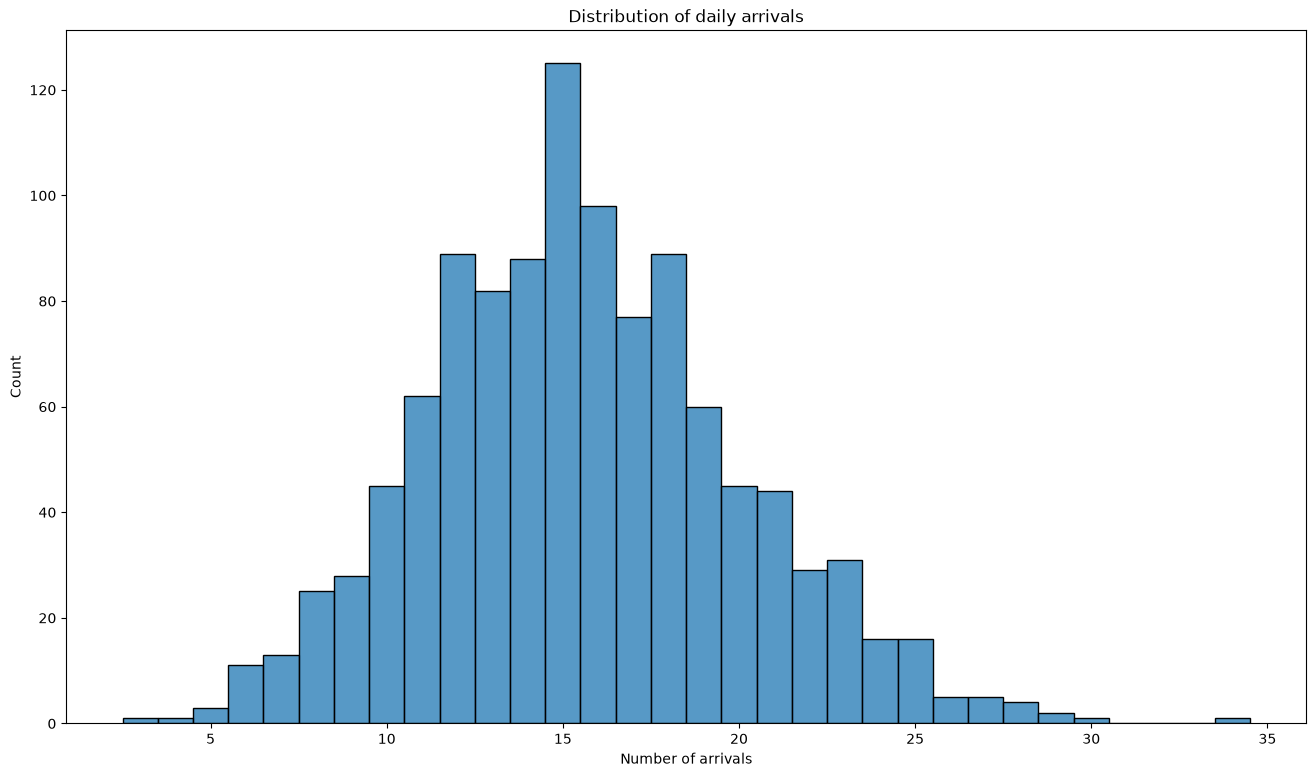

In [7]:
fig, ax = plt.subplots(figsize = (16,9))
sns.histplot(data = daily_counts_total, discrete=True)
ax.set_title("Distribution of daily arrivals")
ax.set_xlabel("Number of arrivals")

Text(0.5, 0, 'Number of arrivals')

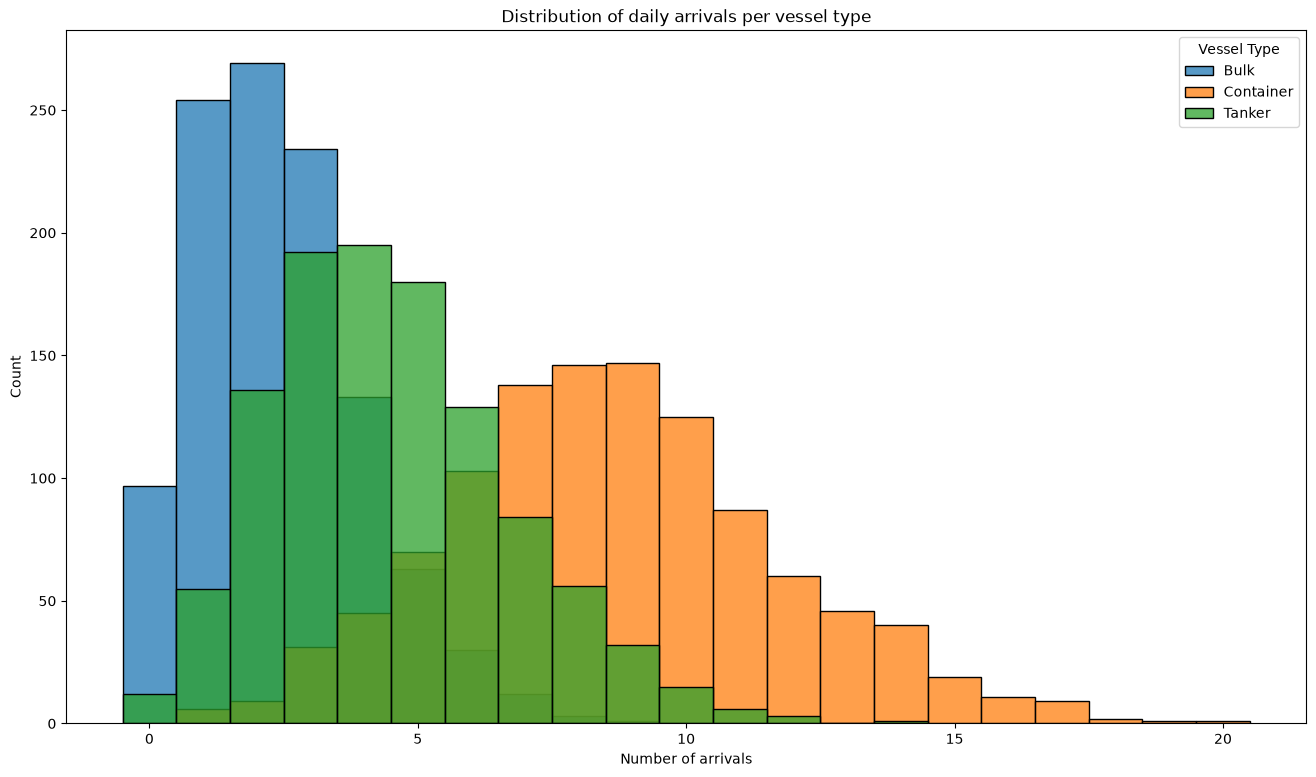

In [8]:
fig, ax = plt.subplots(figsize = (16, 9))
sns.histplot(data = daily_counts_per_type['Bulk'], discrete=True, ax=ax, label="Bulk")
sns.histplot(data = daily_counts_per_type['Container'], discrete=True, ax=ax, label="Container")
sns.histplot(data = daily_counts_per_type['Tanker'], discrete=True, ax=ax, label="Tanker")
ax.legend(title="Vessel Type")
ax.set_title("Distribution of daily arrivals per vessel type")
ax.set_xlabel("Number of arrivals")

### Distribution of inter-arrival times

Text(0.5, 0, 'Minutes between arrivals')

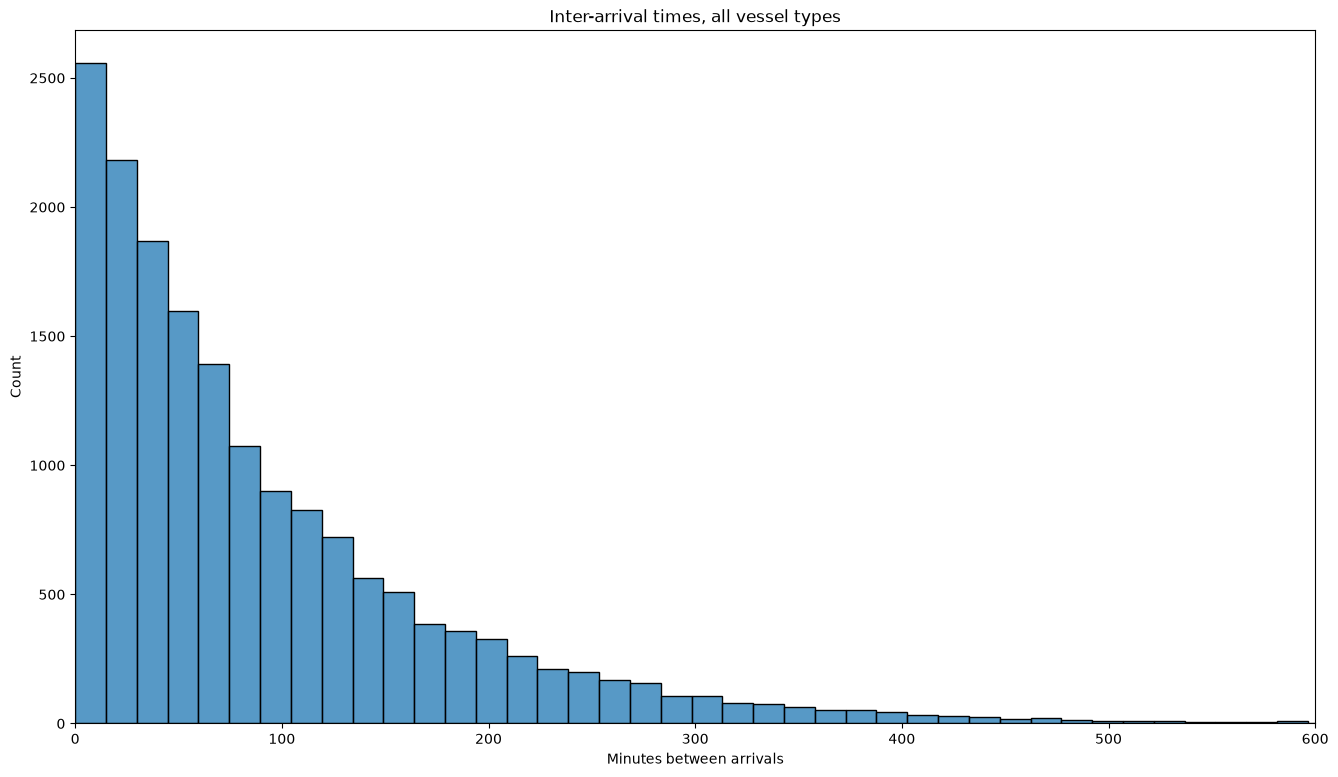

In [9]:
fig, ax = plt.subplots(figsize = (16, 9))
sns.histplot(data = inter_gaps, binwidth=15, ax=ax)
ax.set_xlim(0, 600)
ax.set_title("Inter-arrival times, all vessel types")
ax.set_xlabel("Minutes between arrivals")

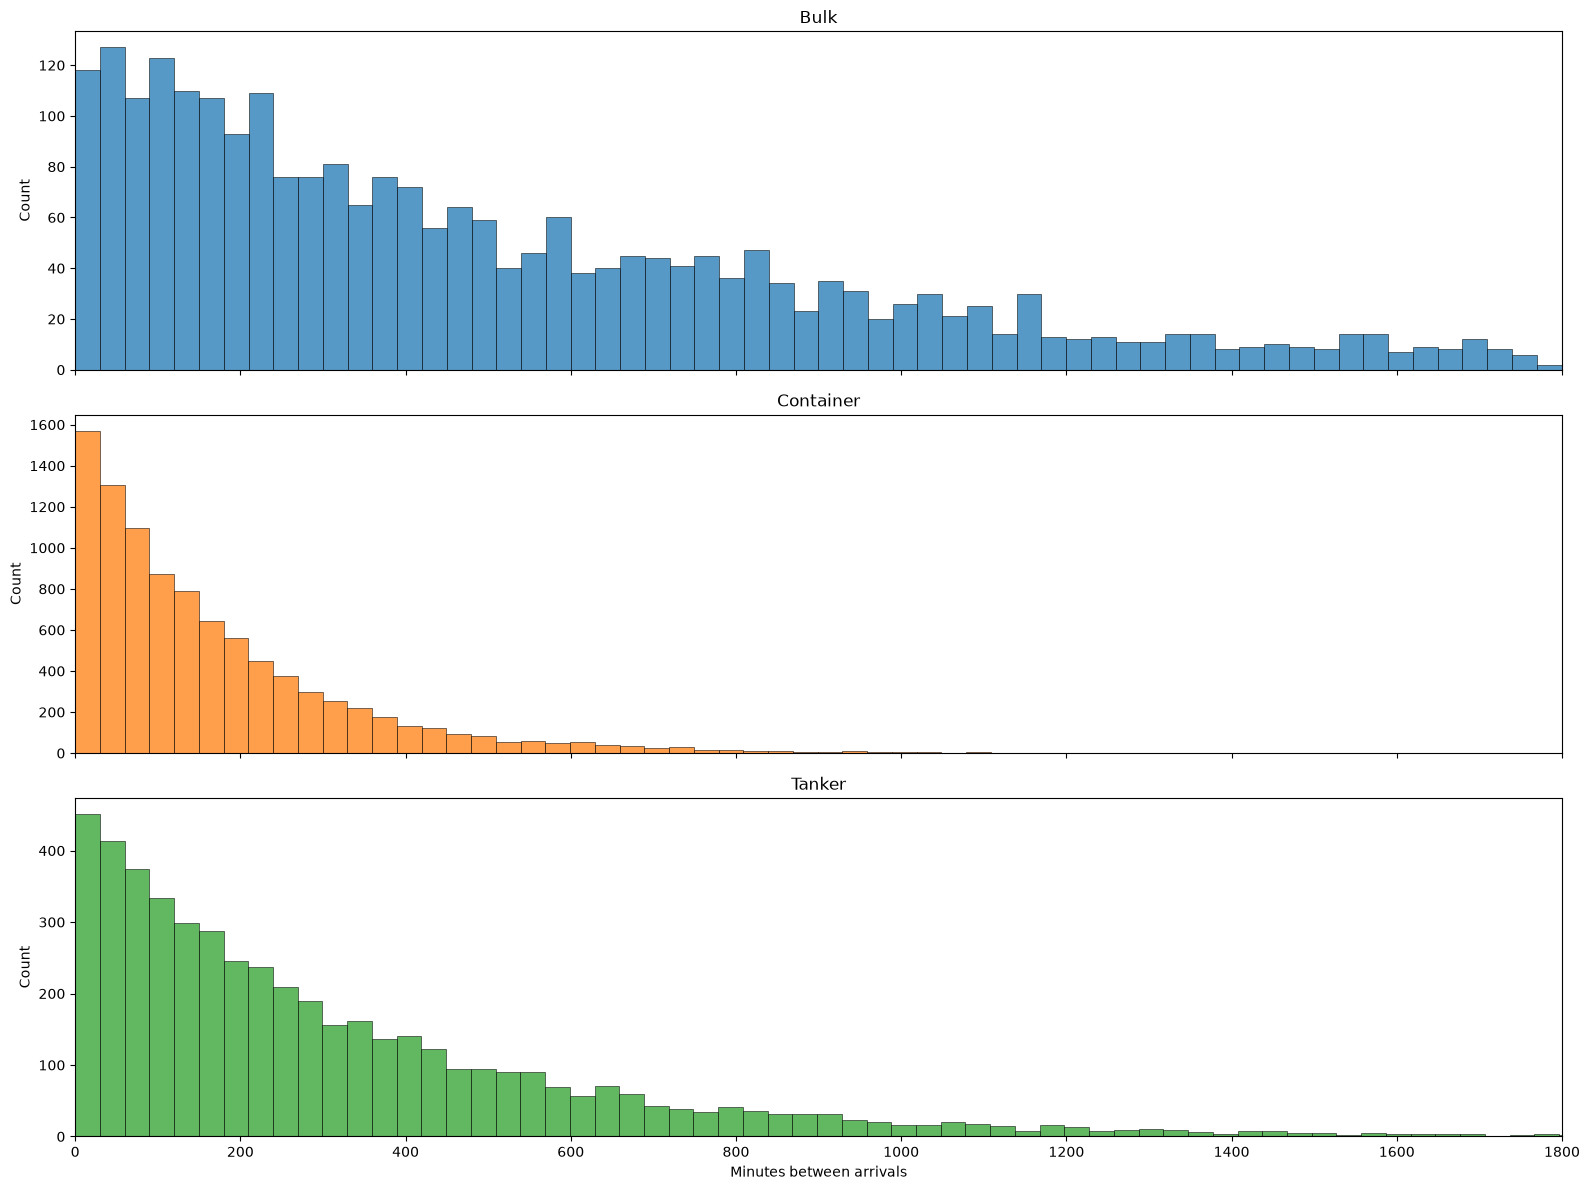

In [10]:
fig, ax = plt.subplots(figsize = (16, 12), nrows=3, ncols=1, sharex=True)

for i, t in enumerate(["Bulk", "Container", "Tanker"]):
    sns.histplot(data = df.loc[df["Vessel_Type"] == t, "gap_min"], binwidth=30,
                 color=f"C{i}", ax=ax[i])
    ax[i].set_title(t)
    ax[i].set_ylabel("Count")

ax[2].set_xlim(0, 1800)
ax[2].set_xlabel("Minutes between arrivals")
plt.tight_layout()

## Arrivals by day of week and hour of day

Each weekday occurs about 156 times in the span and each hour slot once per day,
so those are the denominators - not the total number of days.

In [11]:
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday",
                 "Friday", "Saturday", "Sunday"]

arr_per_day = df.groupby(d.dt.dayofweek).size() / days.dt.dayofweek.value_counts()
arr_per_day.index = weekday_names

arr_per_hour = df.groupby(d.dt.hour).size() / n_days
arr_per_hour.index = range(1, 25)

arr_per_day.round(3)

Monday       15.465
Tuesday      16.045
Wednesday    15.750
Thursday     15.910
Friday       15.301
Saturday     15.223
Sunday       15.401
dtype: float64

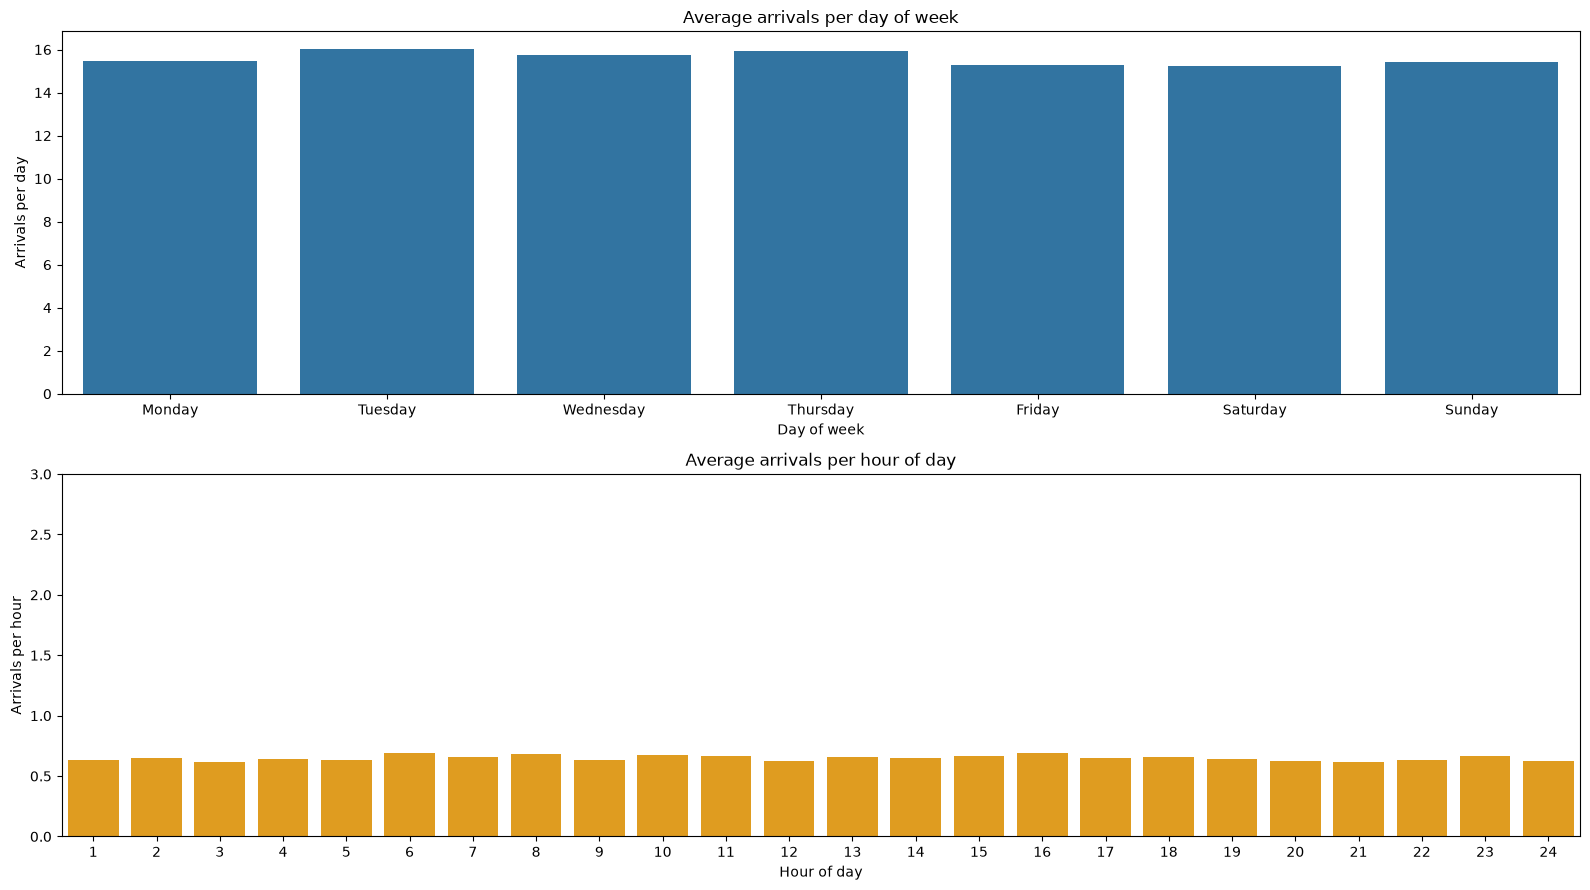

In [12]:
fig, ax = plt.subplots(figsize=(16, 9), nrows=2, ncols=1)

sns.barplot(arr_per_day, ax=ax[0])
ax[0].set_title("Average arrivals per day of week")
ax[0].set_ylabel("Arrivals per day")
ax[0].set_xlabel("Day of week")

sns.barplot(arr_per_hour, ax=ax[1], color="orange")
ax[1].set_title("Average arrivals per hour of day")
ax[1].set_ylabel("Arrivals per hour")
ax[1].set_xlabel("Hour of day")
ax[1].set_ylim(0, 3)

plt.tight_layout()

### Joint weekday x hour rate

The two bar charts are marginals and cannot be combined into a joint table, so
the counts are regrouped on both keys at once.

In [13]:
cross = df.groupby([d.dt.dayofweek, d.dt.hour]).size().unstack(fill_value=0)

wd_occurrences = days.dt.dayofweek.value_counts().sort_index()
rate_wd_hr = cross.div(wd_occurrences, axis=0)
rate_wd_hr.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
rate_wd_hr.round(3)

Arrival_Date,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Mon,0.611,0.675,0.561,0.796,0.624,0.624,0.650,0.643,0.637,0.739,...,0.618,0.682,0.592,0.631,0.675,0.720,0.643,0.599,0.682,0.548
Tue,0.611,0.599,0.624,0.624,0.777,0.650,0.726,0.720,0.631,0.554,...,0.745,0.739,0.669,0.720,0.752,0.611,0.694,0.688,0.618,0.631
Wed,0.628,0.641,0.673,0.564,0.577,0.660,0.603,0.718,0.571,0.782,...,0.692,0.724,0.712,0.667,0.628,0.622,0.551,0.660,0.654,0.660
Thu,0.737,0.699,0.635,0.679,0.609,0.782,0.647,0.654,0.635,0.769,...,0.801,0.724,0.622,0.763,0.615,0.673,0.641,0.571,0.731,0.615
Fri,0.641,0.667,0.538,0.731,0.641,0.692,0.737,0.571,0.615,0.564,...,0.647,0.590,0.699,0.628,0.622,0.551,0.635,0.705,0.596,0.577
Sat,0.650,0.688,0.662,0.573,0.567,0.669,0.618,0.631,0.675,0.599,...,0.497,0.720,0.618,0.592,0.643,0.548,0.541,0.580,0.752,0.675
Sun,0.529,0.586,0.611,0.535,0.662,0.764,0.637,0.822,0.643,0.713,...,0.675,0.682,0.643,0.605,0.567,0.656,0.605,0.650,0.618,0.650


The colour scale is centred on the overall rate with limits at +/- 3 SD of the
cell rates, so a pale cell means the deviation sits inside the spread of the
cells. The chi-square statistic tests whether the 168 cells are flatter or
lumpier than chance would produce.

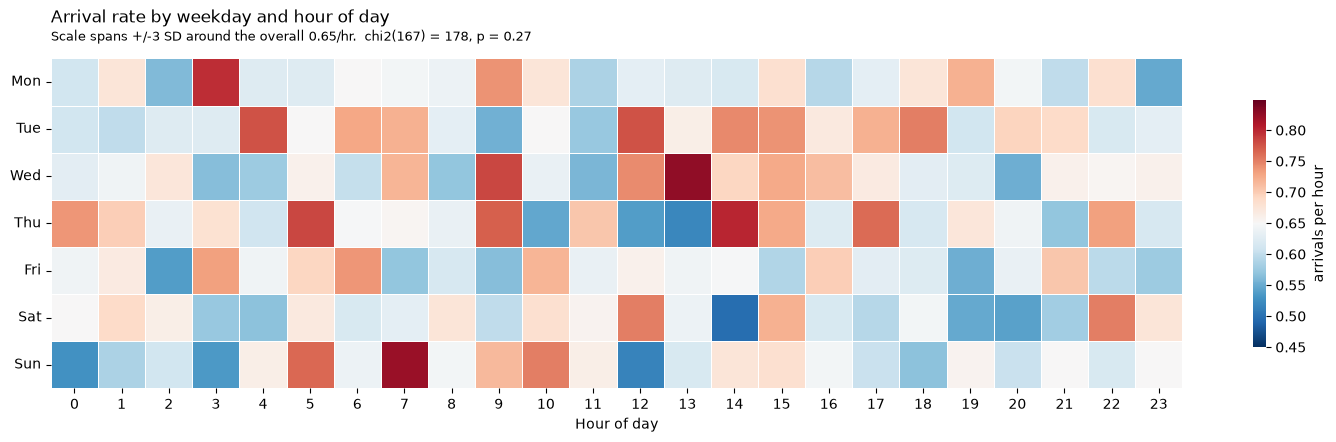

In [14]:
expected = arr_daily / 24
sd_cell = rate_wd_hr.values.std(ddof=1)

exp_count = cross.values.mean()
chi2_stat = ((cross.values - exp_count) ** 2 / exp_count).sum()
dof = cross.size - 1
p_val = chi2.sf(chi2_stat, dof)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    rate_wd_hr, ax=ax, cmap="RdBu_r",
    vmin=expected - 3 * sd_cell, vmax=expected + 3 * sd_cell,
    linewidths=0.5, linecolor="white", square=True,
    cbar_kws={"label": "arrivals per hour", "shrink": 0.75},
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.setp(ax.get_yticklabels(), rotation=0)
ax.set_title("Arrival rate by weekday and hour of day", loc="left", pad=26)
ax.text(0, 1.045,
        f"Scale spans +/-3 SD around the overall {expected:.2f}/hr.  "
        f"chi2({dof}) = {chi2_stat:.0f}, p = {p_val:.2f}",
        transform=ax.transAxes, fontsize=9, va="bottom")
fig.subplots_adjust(top=0.80, bottom=0.14, left=0.045, right=0.99)

## Seasonal effects

The daily series smoothed over a 14-day window, to show the shape of the year
without the day-to-day noise.

Text(0.5, 0, 'Date')

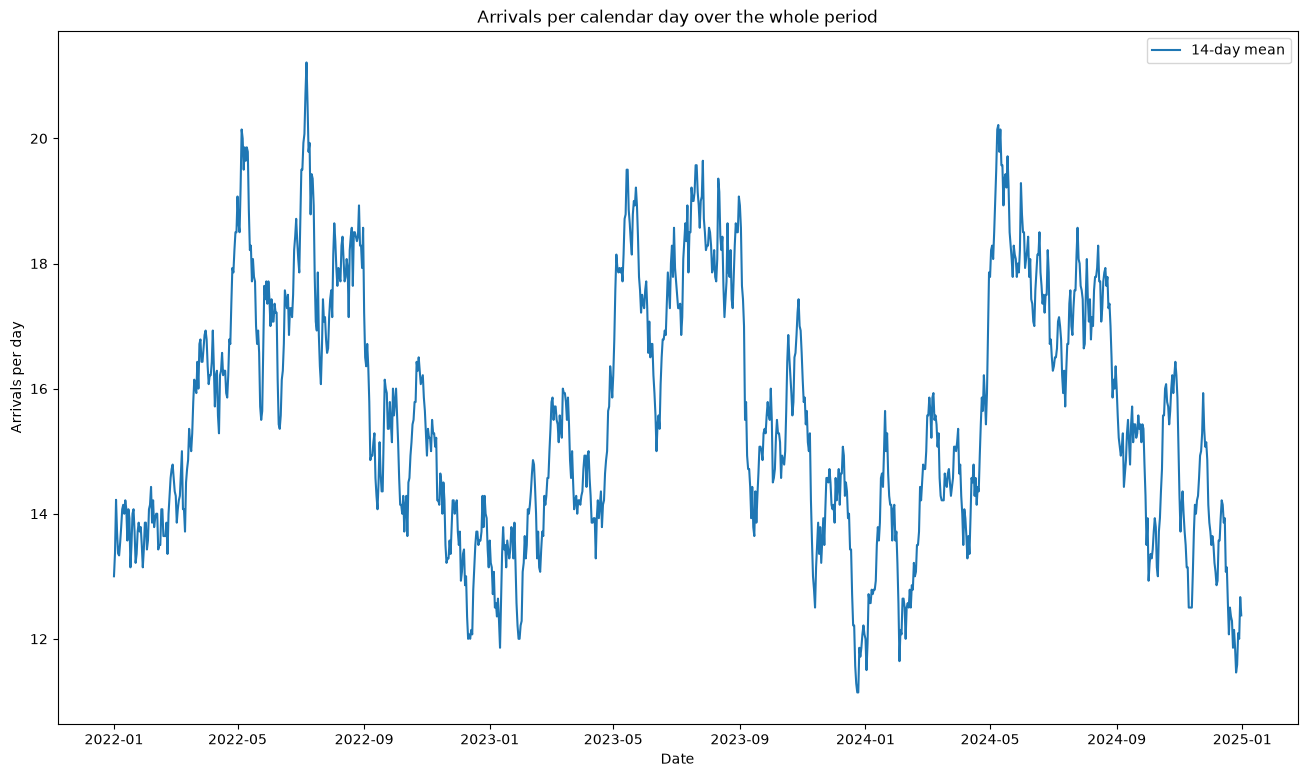

In [15]:
daily_smoothed = daily_counts_total.rolling(window=14, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 9))
sns.lineplot(x=daily_smoothed.index, y=daily_smoothed.values, ax=ax, label="14-day mean")
ax.set_title("Arrivals per calendar day over the whole period")
ax.set_ylabel("Arrivals per day")
ax.set_xlabel("Date")

### Monthly rate per year

Divided by the number of days in each month, so short months such as February
are not mistaken for quiet ones. Three curves of the same shape are what
distinguishes a seasonal pattern from one unusual year.

Arrival_Date,2022,2023,2024
Arrival_Date,,,
1,13.68,12.84,13.71
2,13.79,13.82,13.38
3,15.42,15.13,14.87
4,16.47,14.53,14.70
5,17.87,18.32,18.97
6,17.20,16.70,17.50
7,18.65,18.68,17.39
8,18.13,18.35,17.26
9,15.40,15.13,14.97


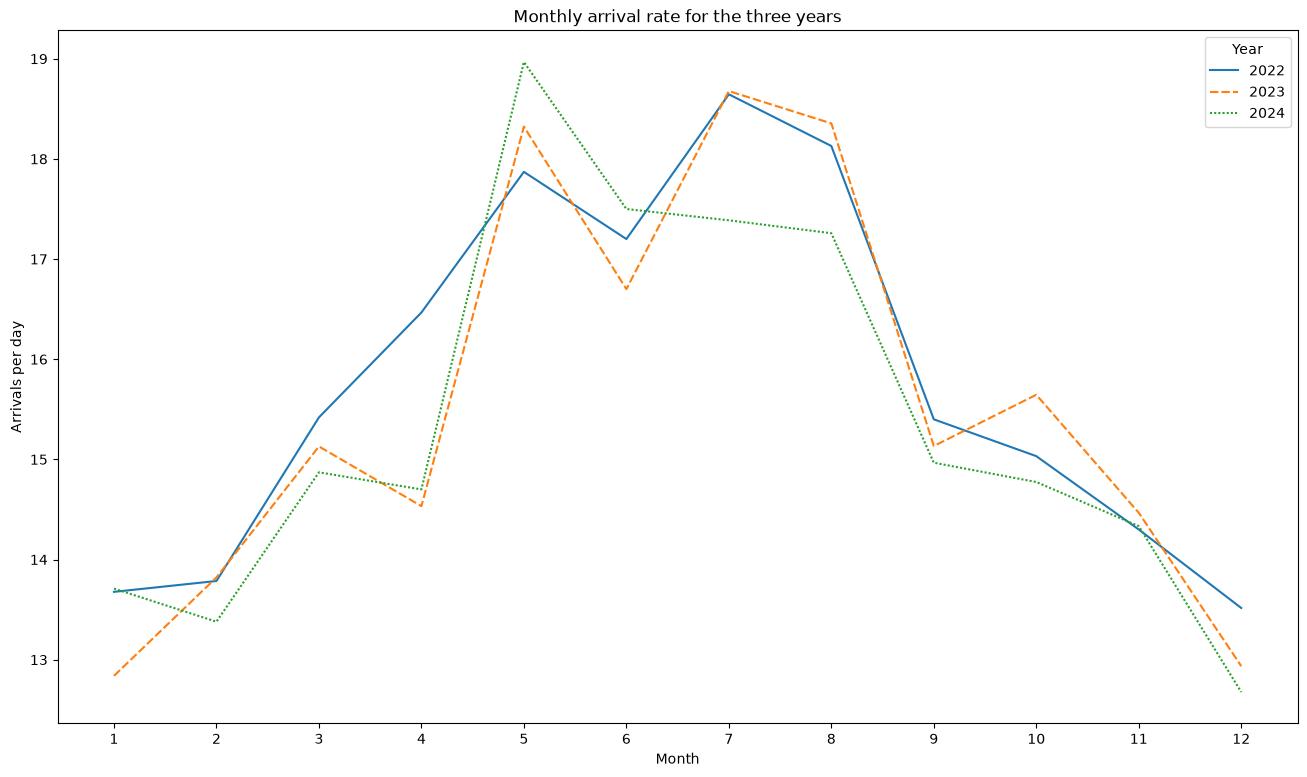

In [16]:
yearly_per_month = (
    df.groupby([d.dt.month, d.dt.year])
      .size()
      .unstack()
)
days_per_month = days.groupby([days.dt.month, days.dt.year]).size().unstack()
yearly_per_month = yearly_per_month / days_per_month

fig, ax = plt.subplots(figsize=(16, 9))
sns.lineplot(data=yearly_per_month, ax=ax)
ax.set_title("Monthly arrival rate for the three years")
ax.set_ylabel("Arrivals per day")
ax.set_xlabel("Month")
ax.set_xticks(range(1, 13))
ax.legend(title="Year")

yearly_per_month.round(2)

### Monthly rate per vessel type

All three years pooled. The denominator is the number of days in each month,
which is the same for every type - a vessel type does not change how much
calendar time elapsed.

Vessel_Type,Bulk,Container,Tanker
Arrival_Date,,,
1,1.97,7.31,4.13
2,2.00,7.91,3.75
3,2.67,8.05,4.42
4,2.41,8.61,4.21
5,2.78,10.39,5.22
6,2.70,9.29,5.14
7,2.60,10.42,5.22
8,2.84,9.87,5.20
9,2.42,8.32,4.42


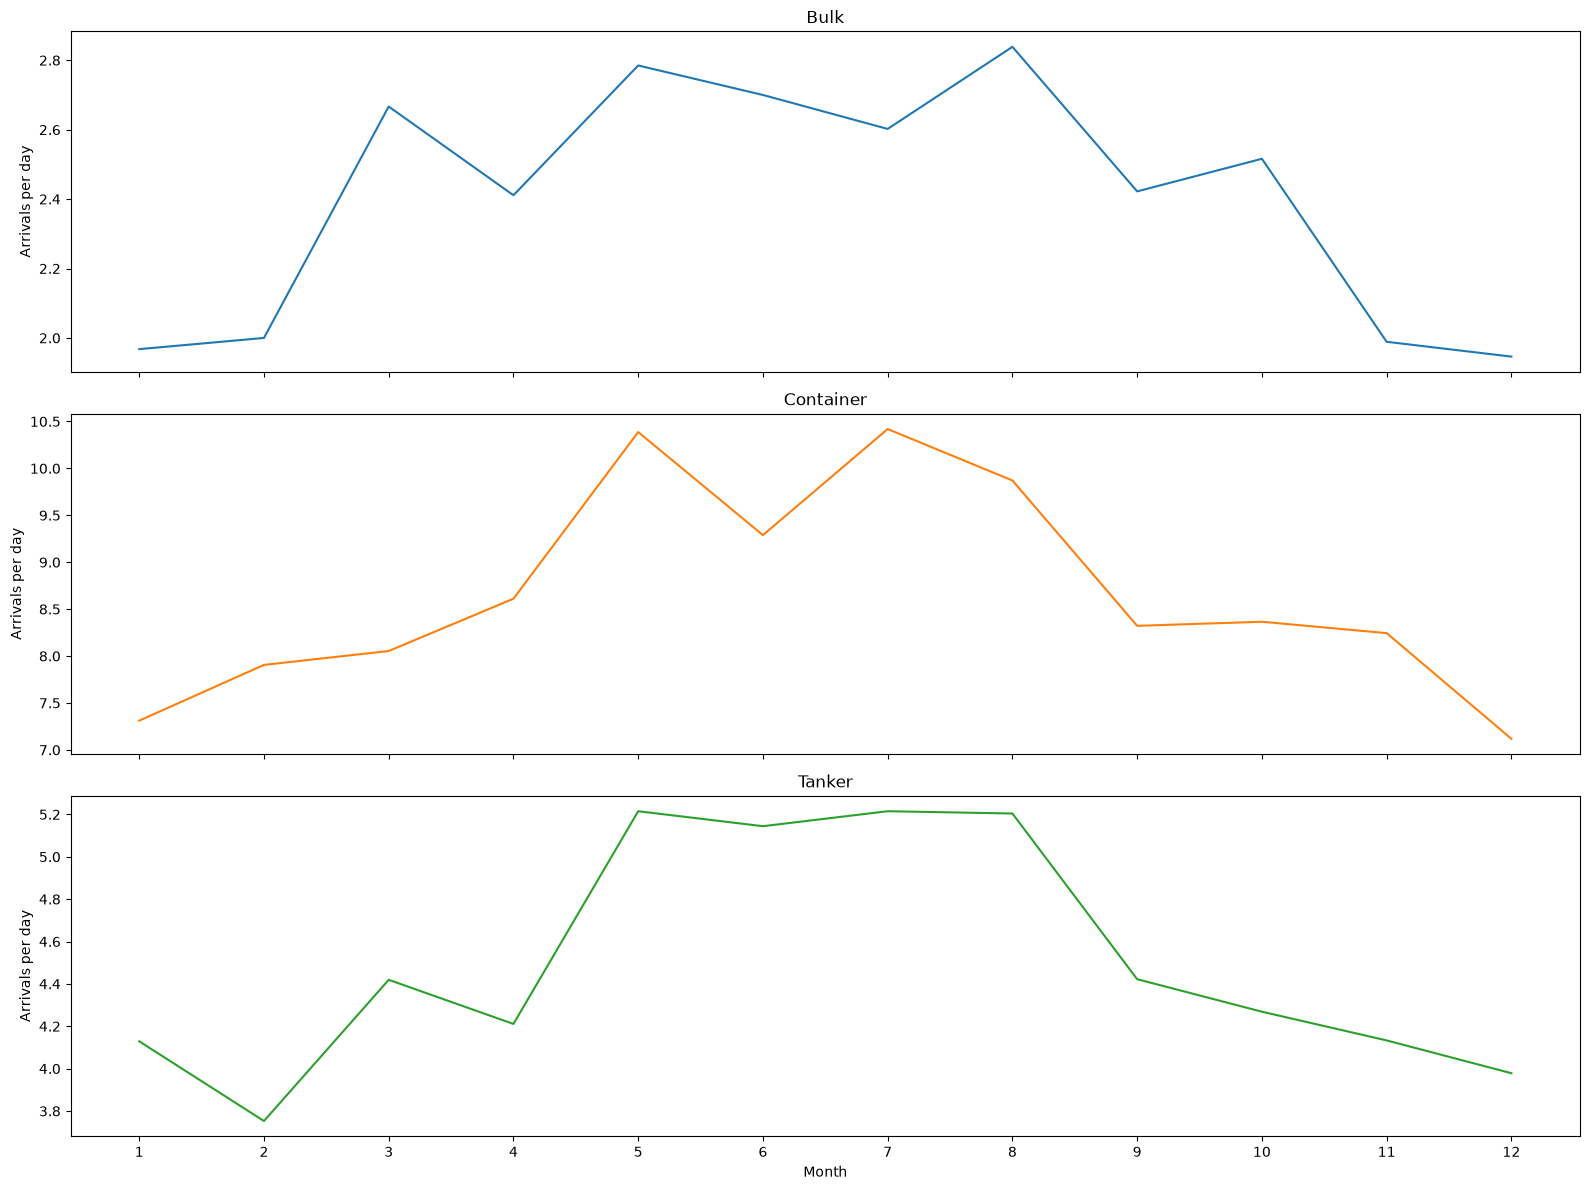

In [17]:
monthly_per_type = (
    df.groupby([d.dt.month, "Vessel_Type"], observed=True)
      .size()
      .unstack()
)
days_per_month_pooled = days.dt.month.value_counts().sort_index()
monthly_per_type = monthly_per_type.div(days_per_month_pooled, axis=0)

fig, ax = plt.subplots(figsize = (16, 12), nrows=3, ncols=1, sharex=True)

for i, t in enumerate(["Bulk", "Container", "Tanker"]):
    sns.lineplot(x=monthly_per_type.index, y=monthly_per_type[t], color=f"C{i}", ax=ax[i])
    ax[i].set_title(t)
    ax[i].set_ylabel("Arrivals per day")

ax[2].set_xticks(range(1, 13))
ax[2].set_xlabel("Month")
plt.tight_layout()

monthly_per_type.round(2)

### Annual means

Standard errors show whether the differences between years are larger than
sampling noise.

In [18]:
yearly = daily_counts_total.groupby(daily_counts_total.index.year).agg(["mean", "std", "count"])
yearly["se"] = yearly["std"] / np.sqrt(yearly["count"])
yearly.index.name = "Year"
yearly.round(3)

,mean,std,count,se
Year,,,,
2022,15.803,4.509,365,0.236
2023,15.564,4.548,365,0.238
2024,15.388,4.276,366,0.224
